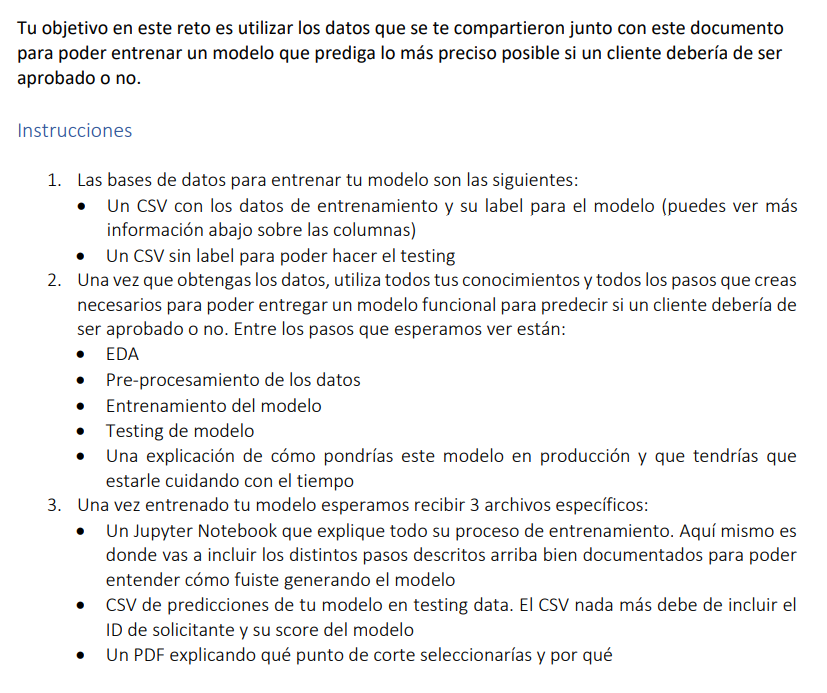

## Especificaciones / Specifications

Este modelo que estamos generando es un modelo de probabilidad de default, lo que significa que los labels son los siguientes:
This model we are building is a default-probability model, meaning the labels are as follows:

• 1 = este cliente va a hacer default (no va a pagar o se va a atrasar por más de 28 días en sus pagos)
• 1 = this client will default (will not pay, or will be more than 28 days late on payments)

• 0 = este cliente NO va a hacer default (siempre va a pagar a tiempo)
• 0 = this client will NOT default (will always pay on time)


## Librerías utilizadas / Libraries used


In [1]:
import pandas as pd 
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


## TestData (Datos de prueba / Test data)


In [30]:
# Carga de datos TEST / Load TEST data
TestData = pd.read_csv("data/Test_Data.csv")
TestData


,ID,edad,montoSolicitado,montoOtorgado,genero,quincenal,dependientesEconomicos,nivelEstudio,score,ingresosMensuales,gastosMensuales,emailScore,browser,NUMTDC_AV
0,1,30.0,20000.0,40000.0,Hombre,1,0,Universidad,575,25000.0,15000,1.0,UNKNOWN,2.0
1,2,31.0,2000.0,2000.0,Hombre,0,4,Preparatoria,635,12000.0,8000,8.0,CHROME9,NaN
2,3,29.0,15000.0,15000.0,Mujer,0,0,Universidad,568,20000.0,14000,0.0,CHROME_MOBILE,1.0
3,4,20.0,7000.0,6000.0,Mujer,0,1,Preparatoria,643,2000.0,6000,1.0,CHROME_MOBILE,NaN
4,5,34.0,18000.0,12999.0,Hombre,1,1,Universidad,546,50000.0,30000,0.0,APPLE_WEB_KIT,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,27.0,1779.0,1779.0,Mujer,1,0,Universidad,511,38000.0,20000,8.0,CHROME9,5.0
296,297,36.0,19700.0,19700.0,Mujer,0,0,Universidad,491,32000.0,17000,0.0,CHROME_MOBILE,3.0
297,298,49.0,6000.0,3000.0,Hombre,1,1,Preparatoria,521,6000.0,3500,0.0,CHROME9,1.0
298,299,29.0,3000.0,3000.0,Mujer,0,1,Universidad,529,10000.0,6000,1.0,CHROME_MOBILE,2.0


In [32]:
# Análisis exploratorio de datos / Exploratory data analysis

TestData.describe()


,ID,edad,montoSolicitado,montoOtorgado,quincenal,dependientesEconomicos,score,ingresosMensuales,gastosMensuales,emailScore,NUMTDC_AV
count,300.000000,297.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,261.000000,184.000000
mean,150.500000,34.259259,17063.395633,12425.624700,0.136667,1.010000,521.956667,25302.525467,13862.790000,1.647510,2.054348
std,86.746758,10.041643,19308.071556,12643.900771,0.344069,1.149335,148.267142,37091.737690,29740.326354,5.404973,1.369968
min,1.000000,18.000000,1000.000000,1000.000000,0.000000,0.000000,0.000000,1200.000000,45.000000,0.000000,1.000000
25%,75.750000,27.000000,6000.000000,4672.762500,0.000000,0.000000,478.750000,10000.000000,5000.000000,0.000000,1.000000
50%,150.500000,32.000000,10650.000000,8000.000000,0.000000,1.000000,558.000000,15000.000000,8000.000000,1.000000,2.000000
75%,225.250000,40.000000,20000.000000,16000.000000,0.000000,2.000000,611.000000,30000.000000,15000.000000,1.000000,3.000000
max,300.000000,68.000000,150000.000000,100000.000000,1.000000,5.000000,703.000000,500000.000000,450000.000000,80.000000,10.000000


In [33]:
# Análisis sobre tipos de datos utilizados / Analysis of data types used

TestData.info()


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      300 non-null    int64  
 1   edad                    297 non-null    float64
 2   montoSolicitado         300 non-null    float64
 3   montoOtorgado           300 non-null    float64
 4   genero                  300 non-null    str    
 5   quincenal               300 non-null    int64  
 6   dependientesEconomicos  300 non-null    int64  
 7   nivelEstudio            300 non-null    str    
 8   score                   300 non-null    int64  
 9   ingresosMensuales       300 non-null    float64
 10  gastosMensuales         300 non-null    int64  
 11  emailScore              261 non-null    float64
 12  browser                 257 non-null    str    
 13  NUMTDC_AV               184 non-null    float64
dtypes: float64(6), int64(5), str(3)
memory usage: 32.9 KB

In [5]:
# Revisión de datos nulos en DataSet / Review of null values in the dataset

TestData.isnull().sum()


ID                          0
edad                        3
montoSolicitado             0
montoOtorgado               0
genero                      0
quincenal                   0
dependientesEconomicos      0
nivelEstudio                0
score                       0
ingresosMensuales           0
gastosMensuales             0
emailScore                 39
browser                    43
NUMTDC_AV                 116
dtype: int64

In [6]:
# Limpieza de Datos, opté por imputar valores con moda (Valor más frecuente) es fácil de calcular, y puede ser una buena aproximación de los valores faltantes porque los valores faltantes son aleatorios y no tienen un patrón específico.
# Data cleaning: I chose to impute values with the mode (most frequent value). It's easy to calculate and can be a good approximation for missing values, since the missing values are random and have no specific pattern.

edad_moda = TestData["edad"].mode()[0]
TestData["edad"].fillna(edad_moda, inplace=True)

emailScore_moda = TestData["emailScore"].mode()[0]
TestData["emailScore"].fillna(emailScore_moda, inplace=True)

NUMTDC_AV_moda = TestData["NUMTDC_AV"].mode()[0]
TestData["NUMTDC_AV"].fillna(NUMTDC_AV_moda, inplace=True)


/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25486/1309751438.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  TestData["edad"].fillna(edad_moda, inplace=True)
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25486/1309751438.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

0      2.0
1      1.0
2      1.0
3      1.0
4      2.0
      ... 
295    5.0
296    3.0
297    1.0
298    2.0
299    1.0
Name: NUMTDC_AV, Length: 300, dtype: float64

In [7]:
# Confirmación de valores nulos / Confirmation of null values

TestData.isnull().sum()


ID                          0
edad                        3
montoSolicitado             0
montoOtorgado               0
genero                      0
quincenal                   0
dependientesEconomicos      0
nivelEstudio                0
score                       0
ingresosMensuales           0
gastosMensuales             0
emailScore                 39
browser                    43
NUMTDC_AV                 116
dtype: int64

In [8]:
# Acomodo y eliminación de columnas que no se necesitan / Arrange and drop columns that are not needed

TestDataID = TestData["ID"]

TestData.drop("ID", axis=1, inplace=True) # Para el modelo no sirve el ID / The ID is not useful for the model

# Considero que la columna browser no es relevante además de que contiene Nan y dificultan el manejo de la información.
# I consider the browser column not relevant, and it also contains NaNs which make the data harder to handle.
TestData.drop("browser", axis=1, inplace=True) 


# DataSet listo para el modelo / Dataset ready for the model
TestData


,edad,montoSolicitado,montoOtorgado,genero,quincenal,dependientesEconomicos,nivelEstudio,score,ingresosMensuales,gastosMensuales,emailScore,NUMTDC_AV
0,30.0,20000.0,40000.0,Hombre,1,0,Universidad,575,25000.0,15000,1.0,2.0
1,31.0,2000.0,2000.0,Hombre,0,4,Preparatoria,635,12000.0,8000,8.0,NaN
2,29.0,15000.0,15000.0,Mujer,0,0,Universidad,568,20000.0,14000,0.0,1.0
3,20.0,7000.0,6000.0,Mujer,0,1,Preparatoria,643,2000.0,6000,1.0,NaN
4,34.0,18000.0,12999.0,Hombre,1,1,Universidad,546,50000.0,30000,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
295,27.0,1779.0,1779.0,Mujer,1,0,Universidad,511,38000.0,20000,8.0,5.0
296,36.0,19700.0,19700.0,Mujer,0,0,Universidad,491,32000.0,17000,0.0,3.0
297,49.0,6000.0,3000.0,Hombre,1,1,Preparatoria,521,6000.0,3500,0.0,1.0
298,29.0,3000.0,3000.0,Mujer,0,1,Universidad,529,10000.0,6000,1.0,2.0


In [9]:
# Confirmación de columnas a utilizar para el modelo / Confirmation of columns to be used for the model

TestData.columns


Index(['edad', 'montoSolicitado', 'montoOtorgado', 'genero', 'quincenal',
       'dependientesEconomicos', 'nivelEstudio', 'score', 'ingresosMensuales',
       'gastosMensuales', 'emailScore', 'NUMTDC_AV'],
      dtype='str')

In [10]:
# Transformación de los datos a un array para el modelo / Transform the data into an array for the model

x_test = TestData.values
x_test


array([[30.0, 20000.0, 40000.0, ..., 15000, 1.0, 2.0],
       [31.0, 2000.0, 2000.0, ..., 8000, 8.0, nan],
       [29.0, 15000.0, 15000.0, ..., 14000, 0.0, 1.0],
       ...,
       [49.0, 6000.0, 3000.0, ..., 3500, 0.0, 1.0],
       [29.0, 3000.0, 3000.0, ..., 6000, 1.0, 2.0],
       [29.0, 3000.0, 3165.0, ..., 4000, 1.0, nan]],
      shape=(300, 12), dtype=object)

In [11]:
# Codificamos para ingresar a modelo / Encode to feed into the model

lb = LabelEncoder()
x_test[:,3] = lb.fit_transform(x_test[:,3]) 
x_test[:,6] = lb.fit_transform(x_test[:,6]) 


## TrainData (Datos de entrenamiento / Training data)


In [12]:
# Carga de datos TRAIN / Load TRAIN data

TrainData = pd.read_csv("data/Train_Data.csv")
TrainData


,ID,label,edad,montoSolicitado,montoOtorgado,genero,quincenal,dependientesEconomicos,nivelEstudio,score,ingresosMensuales,gastosMensuales,emailScore,browser,NUMTDC_AV
0,1,0,38.0,11890.0,11890.00,Hombre,0,1,Universidad,561,7000.0,7000,0.0,CHROME9,1.0
1,2,0,26.0,3700.0,3700.00,Hombre,1,0,Preparatoria,649,8000.0,3000,0.0,CHROME9,1.0
2,3,0,28.0,13980.0,13980.00,Hombre,0,0,Universidad,575,7500.0,2000,NaN,NaN,3.0
3,4,0,27.0,12016.0,6286.00,Hombre,0,0,Universidad,651,12800.0,4300,1.0,UNKNOWN,NaN
4,5,0,31.0,20000.0,12000.00,Hombre,1,1,Universidad,444,20000.0,12000,1.0,MOBILE_SAFARI,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,0,59.0,10000.0,3257.51,Mujer,0,0,Primaria,583,10000.0,2000,10.0,CHROME9,NaN
996,997,1,20.0,19290.0,9277.00,Hombre,1,1,Universidad,600,15000.0,6000,1.0,CHROME9,NaN
997,998,0,31.0,15200.0,15200.00,Hombre,0,0,Universidad,576,25000.0,8500,0.0,CHROME8,2.0
998,999,1,38.0,25000.0,10500.00,Hombre,1,1,Universidad,564,22000.0,8000,NaN,NaN,NaN


In [13]:
# Análisis exploratorio de datos / Exploratory data analysis

TrainData.describe()


,ID,label,edad,montoSolicitado,montoOtorgado,quincenal,dependientesEconomicos,score,ingresosMensuales,gastosMensuales,emailScore,NUMTDC_AV
count,1000.000000,1000.000000,996.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,873.000000,506.000000
mean,500.500000,0.220000,34.588353,15871.090740,11871.470470,0.156000,0.995000,533.60800,24852.949160,12692.456000,1.882016,2.203557
std,288.819436,0.414454,10.176296,17109.302264,12951.028413,0.363037,1.127939,141.94502,38290.063995,28816.956572,5.325080,1.518228
min,1.000000,0.000000,18.000000,1000.000000,1000.000000,0.000000,0.000000,0.00000,12.000000,2.000000,0.000000,1.000000
25%,250.750000,0.000000,27.000000,5289.500000,4393.750000,0.000000,0.000000,491.00000,10000.000000,4000.000000,0.000000,1.000000
50%,500.500000,0.000000,32.000000,11000.000000,7795.000000,0.000000,1.000000,560.00000,16000.000000,7000.000000,1.000000,2.000000
75%,750.250000,0.000000,40.000000,19000.000000,15000.000000,0.000000,2.000000,618.25000,25000.000000,14000.000000,1.000000,3.000000
max,1000.000000,1.000000,69.000000,150000.000000,100000.000000,1.000000,5.000000,748.00000,900000.000000,750000.000000,80.000000,12.000000


In [14]:
# Análisis sobre tipos de datos utilizados / Analysis of data types used

TrainData.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      1000 non-null   int64  
 1   label                   1000 non-null   int64  
 2   edad                    996 non-null    float64
 3   montoSolicitado         1000 non-null   float64
 4   montoOtorgado           1000 non-null   float64
 5   genero                  1000 non-null   str    
 6   quincenal               1000 non-null   int64  
 7   dependientesEconomicos  1000 non-null   int64  
 8   nivelEstudio            1000 non-null   str    
 9   score                   1000 non-null   int64  
 10  ingresosMensuales       1000 non-null   float64
 11  gastosMensuales         1000 non-null   int64  
 12  emailScore              873 non-null    float64
 13  browser                 871 non-null    str    
 14  NUMTDC_AV               506 non-null    float64
dtyp

In [15]:
# Revisión de datos nulos en DataSet / Review of null values in the dataset

TrainData.isnull().sum()


ID                          0
label                       0
edad                        4
montoSolicitado             0
montoOtorgado               0
genero                      0
quincenal                   0
dependientesEconomicos      0
nivelEstudio                0
score                       0
ingresosMensuales           0
gastosMensuales             0
emailScore                127
browser                   129
NUMTDC_AV                 494
dtype: int64

In [16]:
# Limpieza de Datos, opté por imputar valores con moda (Valor más frecuente) es fácil de calcular, y puede ser una buena aproximación de los valores faltantes porque los valores faltantes son aleatorios y no tienen un patrón específico.
# Data cleaning: I chose to impute values with the mode (most frequent value). It's easy to calculate and can be a good approximation for missing values, since the missing values are random and have no specific pattern.

edad_moda = TrainData["edad"].mode()[0]
TrainData["edad"].fillna(edad_moda, inplace=True)

emailScore_moda = TrainData["emailScore"].mode()[0]
TrainData["emailScore"].fillna(emailScore_moda, inplace=True)

NUMTDC_AV_moda = TrainData["NUMTDC_AV"].mode()[0]
TrainData["NUMTDC_AV"].fillna(NUMTDC_AV_moda, inplace=True)


/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25486/1023956393.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  TrainData["edad"].fillna(edad_moda, inplace=True)
/var/folders/4k/2h1pyx6s2tvc0p940krlsdb40000gn/T/ipykernel_25486/1023956393.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Se

0      1.0
1      1.0
2      3.0
3      1.0
4      1.0
      ... 
995    1.0
996    1.0
997    2.0
998    1.0
999    2.0
Name: NUMTDC_AV, Length: 1000, dtype: float64

In [17]:
# Confirmación de valores nulos / Confirmation of null values

TrainData.isnull().sum()


ID                          0
label                       0
edad                        4
montoSolicitado             0
montoOtorgado               0
genero                      0
quincenal                   0
dependientesEconomicos      0
nivelEstudio                0
score                       0
ingresosMensuales           0
gastosMensuales             0
emailScore                127
browser                   129
NUMTDC_AV                 494
dtype: int64

In [18]:
# Acomodo y eliminación de columnas que no se necesitan / Arrange and drop columns that are not needed

TrainData["y"] = TrainData["label"]
TrainData.drop("ID", axis=1, inplace=True)
TrainData.drop("label", axis=1, inplace=True)
TrainData.drop("browser", axis=1, inplace=True) # Considero que la columna browser no es relevante además de que contiene Nan y dificultan el manejo de la información. / I consider the browser column not relevant, and it also contains NaNs which make the data harder to handle.


# DataSet listo para el modelo / Dataset ready for the model
TrainData


,edad,montoSolicitado,montoOtorgado,genero,quincenal,dependientesEconomicos,nivelEstudio,score,ingresosMensuales,gastosMensuales,emailScore,NUMTDC_AV,y
0,38.0,11890.0,11890.00,Hombre,0,1,Universidad,561,7000.0,7000,0.0,1.0,0
1,26.0,3700.0,3700.00,Hombre,1,0,Preparatoria,649,8000.0,3000,0.0,1.0,0
2,28.0,13980.0,13980.00,Hombre,0,0,Universidad,575,7500.0,2000,NaN,3.0,0
3,27.0,12016.0,6286.00,Hombre,0,0,Universidad,651,12800.0,4300,1.0,NaN,0
4,31.0,20000.0,12000.00,Hombre,1,1,Universidad,444,20000.0,12000,1.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,59.0,10000.0,3257.51,Mujer,0,0,Primaria,583,10000.0,2000,10.0,NaN,0
996,20.0,19290.0,9277.00,Hombre,1,1,Universidad,600,15000.0,6000,1.0,NaN,1
997,31.0,15200.0,15200.00,Hombre,0,0,Universidad,576,25000.0,8500,0.0,2.0,0
998,38.0,25000.0,10500.00,Hombre,1,1,Universidad,564,22000.0,8000,NaN,NaN,1


In [19]:
# Transformación de los datos a un array para el modelo / Transform the data into an array for the model

# Separo valores de X / Split out the X values
x_train = TrainData.iloc[:,0:12].values # Atributo que trae solo los valores en forma de Array (Arreglo). Elimina los headers que no son necesarios para ingresar al algorítmo. / Attribute that returns only the values as an Array. Removes the headers, which are not needed to feed the algorithm.
x_train


array([[38.0, 11890.0, 11890.0, ..., 7000, 0.0, 1.0],
       [26.0, 3700.0, 3700.0, ..., 3000, 0.0, 1.0],
       [28.0, 13980.0, 13980.0, ..., 2000, nan, 3.0],
       ...,
       [31.0, 15200.0, 15200.0, ..., 8500, 0.0, 2.0],
       [38.0, 25000.0, 10500.0, ..., 8000, nan, nan],
       [30.0, 20000.0, 40000.0, ..., 15000, 1.0, 2.0]],
      shape=(1000, 12), dtype=object)

In [20]:
# Separo valores de Y / Split out the Y values
y_train = TrainData.iloc[:,-1:].values  
y_train


array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
    

In [21]:
# Codificamos para ingresar al modelo / Encode to feed into the model
lb = LabelEncoder()
x_train[:,3] = lb.fit_transform(x_train[:,3]) 
x_train[:,6] = lb.fit_transform(x_train[:,6]) 


## Modelo / Model


In [22]:
print("Datos de entrenamiento X" , x_train.shape)
print("Datos de entrenamiento y", y_train.shape)
print("Datos de prueba X", x_test.shape)

Datos de entrenamiento X (1000, 12)
Datos de entrenamiento y (1000, 1)
Datos de prueba X (300, 12)


In [23]:
# Entrenamiento del modelo Decision Tree / Training the Decision Tree model

dt = DecisionTreeClassifier(random_state=1)
dt.fit(x_train,y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [24]:
# Predicción de el data set TEST / Prediction on the TEST dataset

y_prediccion = dt.predict(x_test)
y_prediccion


array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0])

In [25]:
# Testing aleatorio de los datos de test aplicando el entrenamiento y modelo / Random testing of test data using the trained model

# 1 = este cliente va a hacer default (no va a pagar o se va a atrasar por más de 28 días en sus pagos) / 1 = this client will default (will not pay, or will be more than 28 days late)
# 0 = este cliente NO va a hacer default (siempre va a pagar a tiempo) / 0 = this client will NOT default (will always pay on time)

Xsample = pd.DataFrame(x_test)
Xsample= Xsample.sample().values

# Predicciones / Predictions
ynueva = dt.predict(Xsample)

print("Clientes con estos valores " , Xsample)
print("El modelo predice que serría default o no: " , ynueva)


Clientes con estos valores  [[47.0 10000.0 10000.0 0 0 2 4 565 9000.0 5500 6.0 1.0]]
El modelo predice que serría default o no:  [1]


Pondría este modelo en marcha haciendo que se recopile información sólo de las columnas de mayor importancia para el modelo. Se podría intentar automatizar la forma en que se preparan los datos para que sea sencillo correr el modelo y tener validaciones express, o al menos en un menor número de tiempo.

I would put this model into production by collecting data only for the columns of greatest importance to the model. One could try to automate the way the data is prepared so that running the model and getting quick validations becomes easy, or at least takes much less time.


Una vez que el modelo esté en marcha, es importante cuidarlo con el tiempo para asegurarse de que sigue siendo preciso y relevante.

Once the model is in production, it's important to look after it over time to make sure it stays accurate and relevant.

Necesitará un monitoreo constante del rendimiento y verificar si hay cambios en el comportamiento o precisión del modelo. Igualmente es importante asegurarse de que los datos se actualicen regularmente para reflejar los cambios en el mundo real e incluso reentrenar el modelo con nuevos datos para asegurarse de que sigue siendo actual.

It will need constant performance monitoring and checks for changes in the model's behavior or accuracy. It's also important to make sure the data is updated regularly to reflect real-world changes, and even to retrain the model with new data to keep it up to date.


# Árbol de decisión / Decision tree


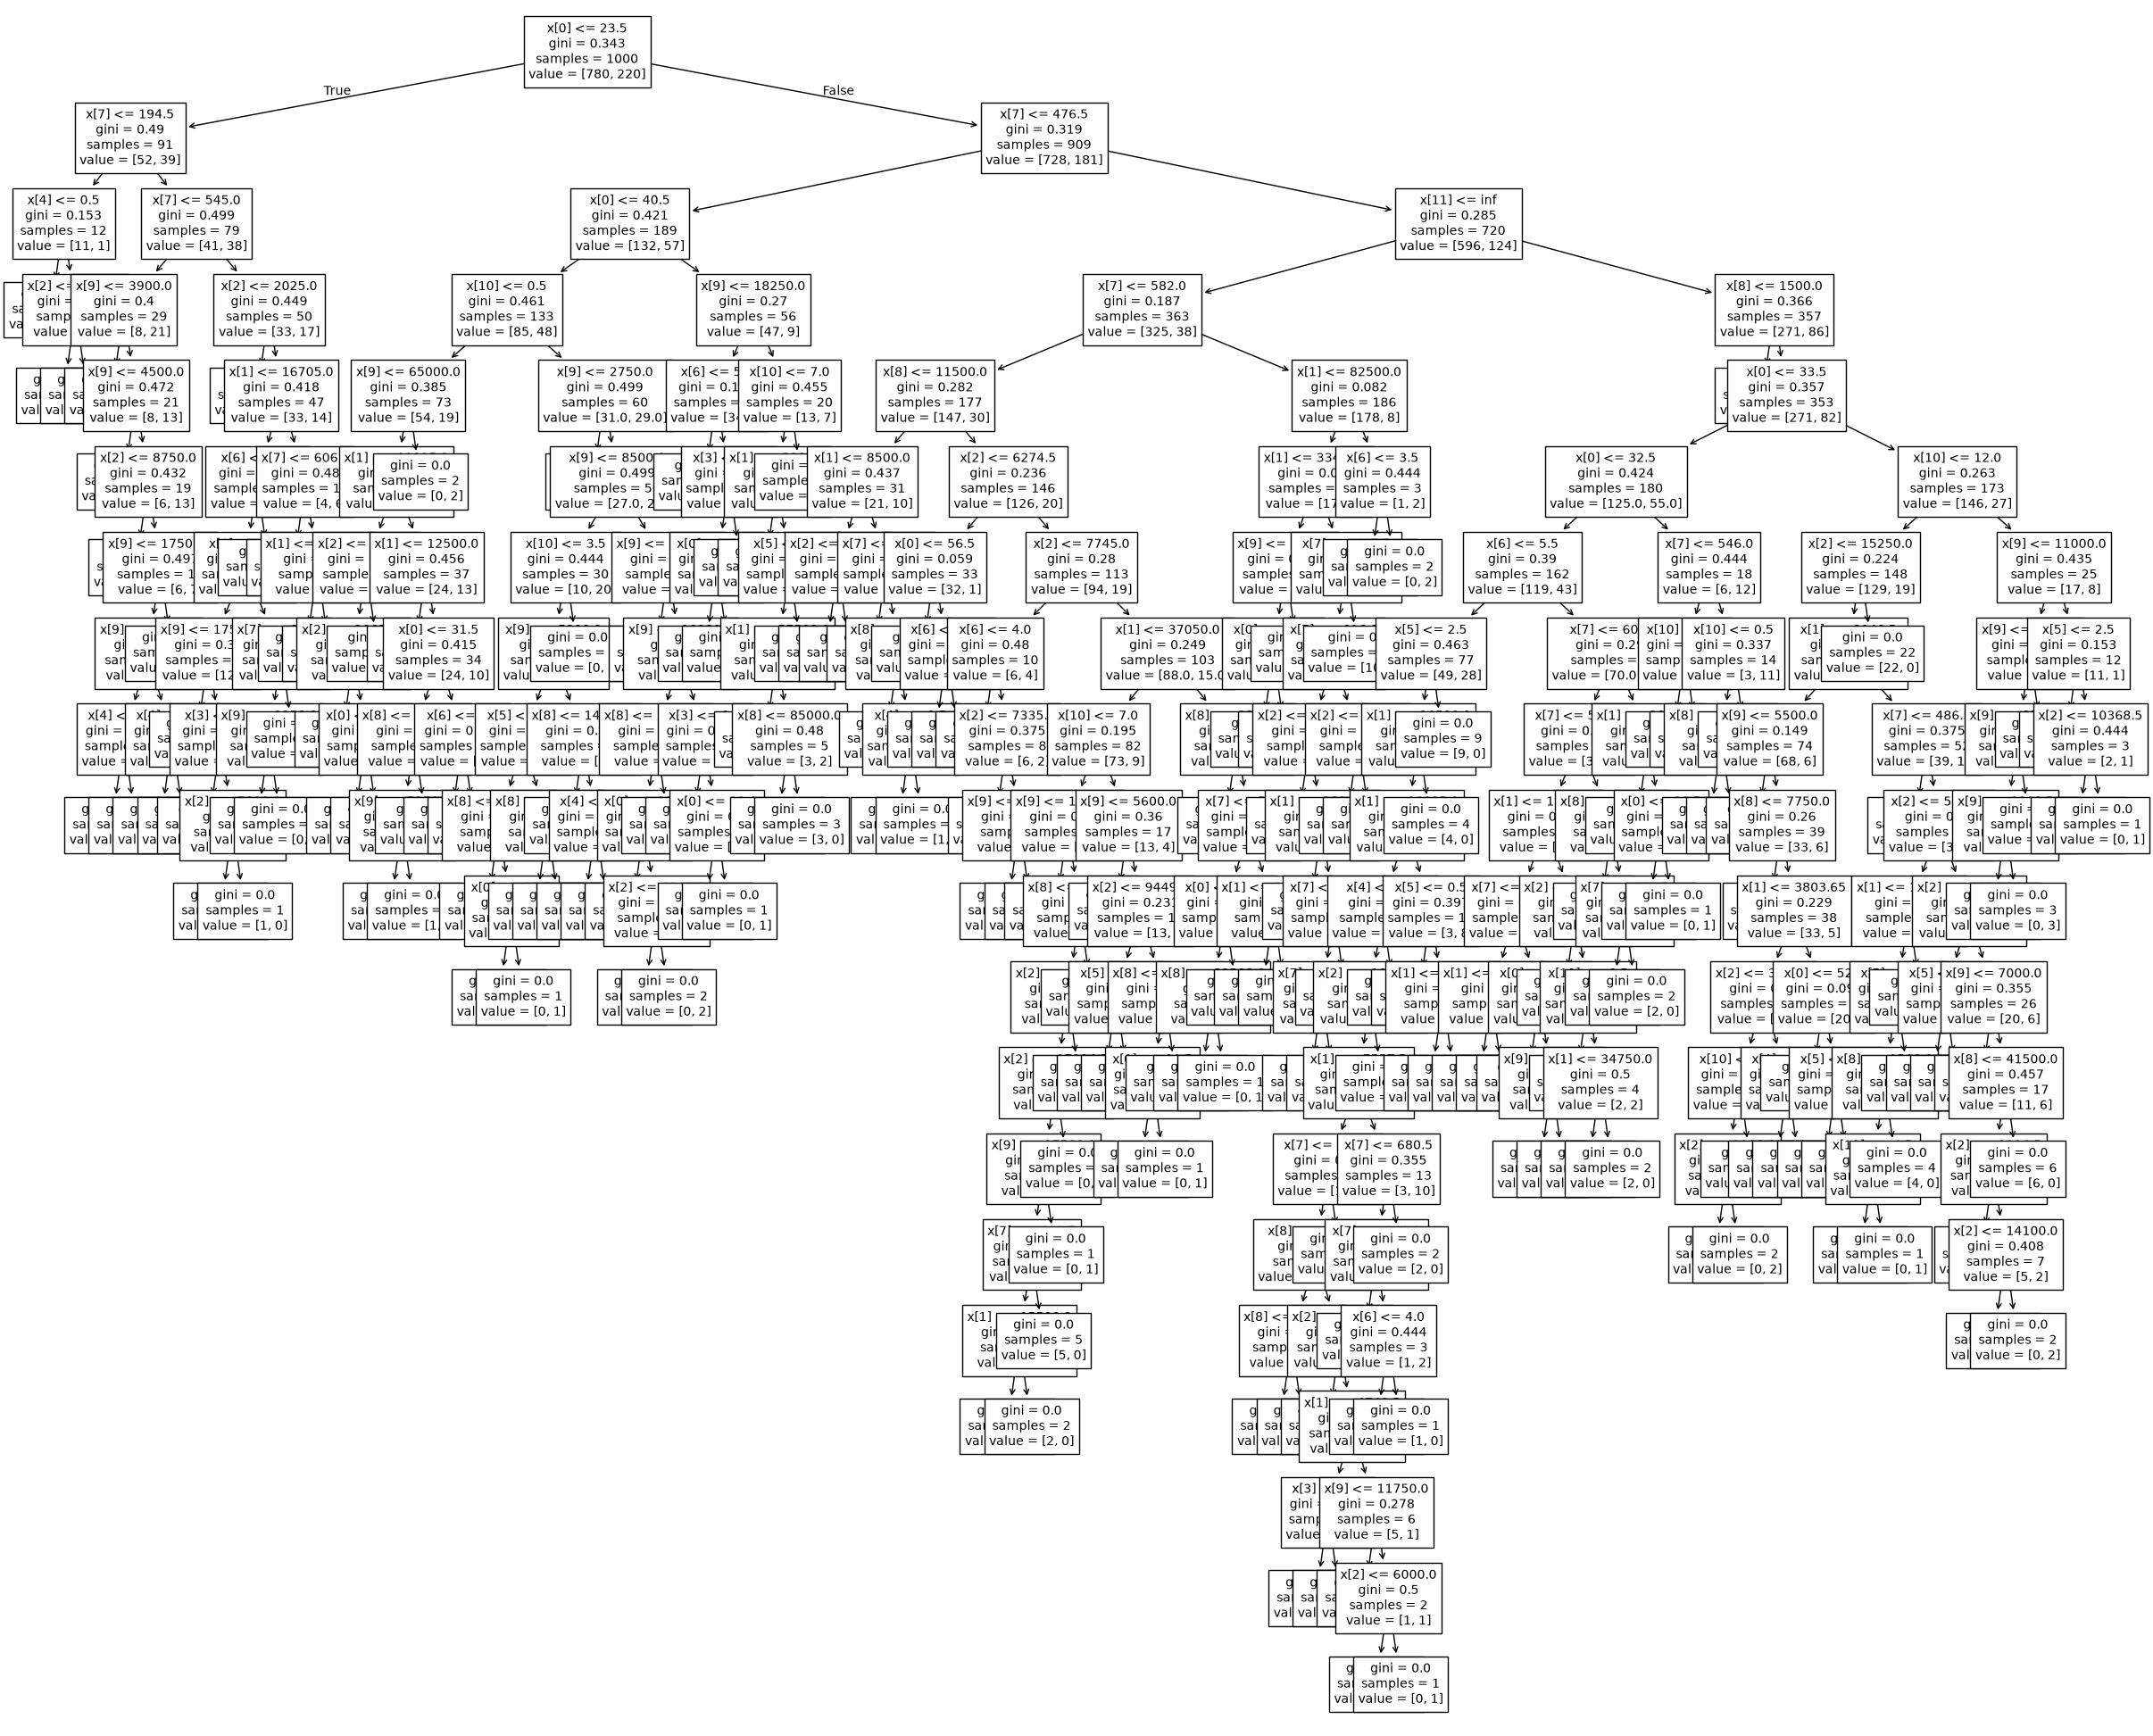

In [26]:

# Gráfica del árbol de decisión / Decision tree plot
plt.figure(figsize = (30,25))
tree.plot_tree(dt,fontsize = 10)
plt.show()


atributo: edad, importancia: 0.1089
atributo: montoSolicitado, importancia: 0.1240
atributo: montoOtorgado, importancia: 0.1405
atributo: genero, importancia: 0.0129
atributo: quincenal, importancia: 0.0327
atributo: dependientesEconomicos, importancia: 0.0467
atributo: nivelEstudio, importancia: 0.0599
atributo: score, importancia: 0.1398
atributo: ingresosMensuales, importancia: 0.1137
atributo: gastosMensuales, importancia: 0.1491
atributo: emailScore, importancia: 0.0523
atributo: NUMTDC_AV, importancia: 0.0195


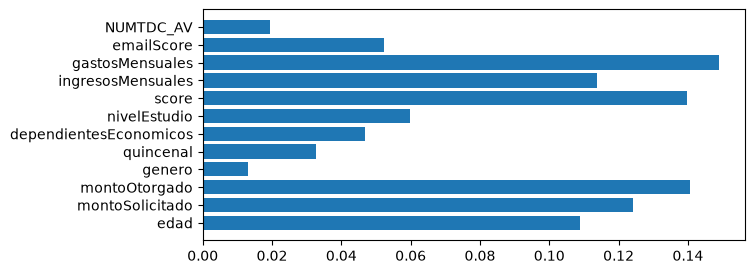

In [27]:
# Feature Importances según las columnas / Feature importances by column
fn = ['edad', 'montoSolicitado', 'montoOtorgado', 'genero', 'quincenal',
       'dependientesEconomicos', 'nivelEstudio', 'score', 'ingresosMensuales',
       'gastosMensuales', 'emailScore', 'NUMTDC_AV']
FI = dt.feature_importances_

for feature,importancia in zip(fn, FI):
  print('atributo: {}, importancia: {:.4f}'.format(feature,importancia))

plt.figure(figsize=(7,3))
plt.barh(fn,FI)
plt.show()


## CSV de predicciones de tu modelo en testing data. El CSV nada más debe de incluir el ID de solicitante y su score del modelo / CSV of your model's predictions on the test data. The CSV should only include the applicant's ID and their model score.


In [28]:
TestDataID = pd.DataFrame(TestDataID)
resultado = pd.DataFrame(y_prediccion)

TestDataID["resultado"]= resultado[0]
TestDataID

,ID,resultado
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
295,296,0
296,297,1
297,298,0
298,299,0


In [29]:
# Guardar CSV / Save CSV
#TestDataID.to_csv('Modelo_Final.csv', index=False)


La variable más significativa para este modelo es el Score con un 18.79% de importancia, luego de Monto Otorgado con un 16.29% y Gastos Mensuales con 12.16% para mi el punto de corte serían principalmente estas 3 variables, ya que son las que tienen más peso para el modelo para poder clasificar la salida como positiva o negativa.

The most significant variable for this model is Score, with 18.79% importance, followed by Monto Otorgado (Amount Granted) with 16.29% and Gastos Mensuales (Monthly Expenses) with 12.16%. In my view, the cutoff point would mainly be these 3 variables, since they carry the most weight for the model in classifying the output as positive or negative.
